In [1]:
import jax

# jax.config.update("jax_enable_x64", False)
jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_platform_name", "gpu")
jax.config.update("jax_debug_nans", True)
print(jax.local_devices()[0].device_kind)
from jax import numpy as np, random as jr, tree as jtu
import os


import zodiax as zdx
from zodiax.optimisation import sgd, adam
import dLux.utils as dlu

from amigo.fitting import Trainer
import dorito


# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots
import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

NVIDIA GeForce RTX 2080 Ti


/home/max/miniforge3/envs/nuke/lib/python3.13/site-packages/amigo/optical_models.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


In [2]:
from socket import gethostname

if gethostname() == "glinton":
    morgana = "/media/morgana1/"
else:
    morgana = "/Volumes/morgana1/"

data_path = os.path.join(morgana, "snert/max/data/JWST/NGC1068/calslope/")
uncal_path = os.path.join(morgana, "snert/max/data/JWST/NGC1068/uncal/")
amigo_cache = os.path.join(morgana, "snert/max/data/amigo_files/")

cache = os.path.join(amigo_cache, "v_0.0.10/")
output_path = os.path.join(amigo_cache, "outputs/NGC1068/")

load_dict = lambda x: np.load(x, allow_pickle=True).item()
cal_vis_outputs = load_dict(os.path.join(output_path, "cal_vis.npy"))

print(cal_vis_outputs.keys())

dict_keys(['F380M', 'F430M', 'F480M'])


In [3]:
optics_diameter = 6.603464  # JWST aperture diameter in meters
otf_coords = dlu.pixel_coords(51, 2 * optics_diameter)

ois = [
    dorito.model_fits.ResolvedOIFit(oi_data, key, filter=key)
    for key, oi_data in cal_vis_outputs.items()
]
# ois = [ois[-1]]
for oi in ois:
    print(oi.key)

s = 121
distribution = np.ones((s, s))

model = dorito.models.ResolvedDiscoModel(
    ois,
    distribution,
    uv_npixels=2 * otf_coords.shape[-1],
    uv_pscale=0.5 * np.diff(otf_coords[0, 0]).mean(),
    oversample=4.0,
)

# # Initialise at the mean dirty image
# otf = np.load("files/otf_support.npy")

# params = {"log_dist": {}, "base_uv": model.params["base_uv"]}
# hypot = lambda x: np.sqrt(np.array([_x**2 for _x in x]).sum(0))
# for filt in ["F380M", "F430M", "F480M"]:
#     dirty_imgs = [
#         oi.dirty_image(model, rotate=True, otf_support=otf)
#         for oi in ois
#         if oi.filter == filt
#     ]

#     if dirty_imgs == []:
#         print(f"No dirty images for filter {filt}, skipping initialisation.")
#         continue
#     mean_dirty = hypot(dirty_imgs)
#     init_dist = np.log10(mean_dirty / mean_dirty.sum() + 1e-16)
#     for oi in ois:
#         if oi.filter == filt:
#             params["log_dist"][oi.get_key("log_dist")] = init_dist

# model = model.set("params", params)

F380M
F430M
F480M


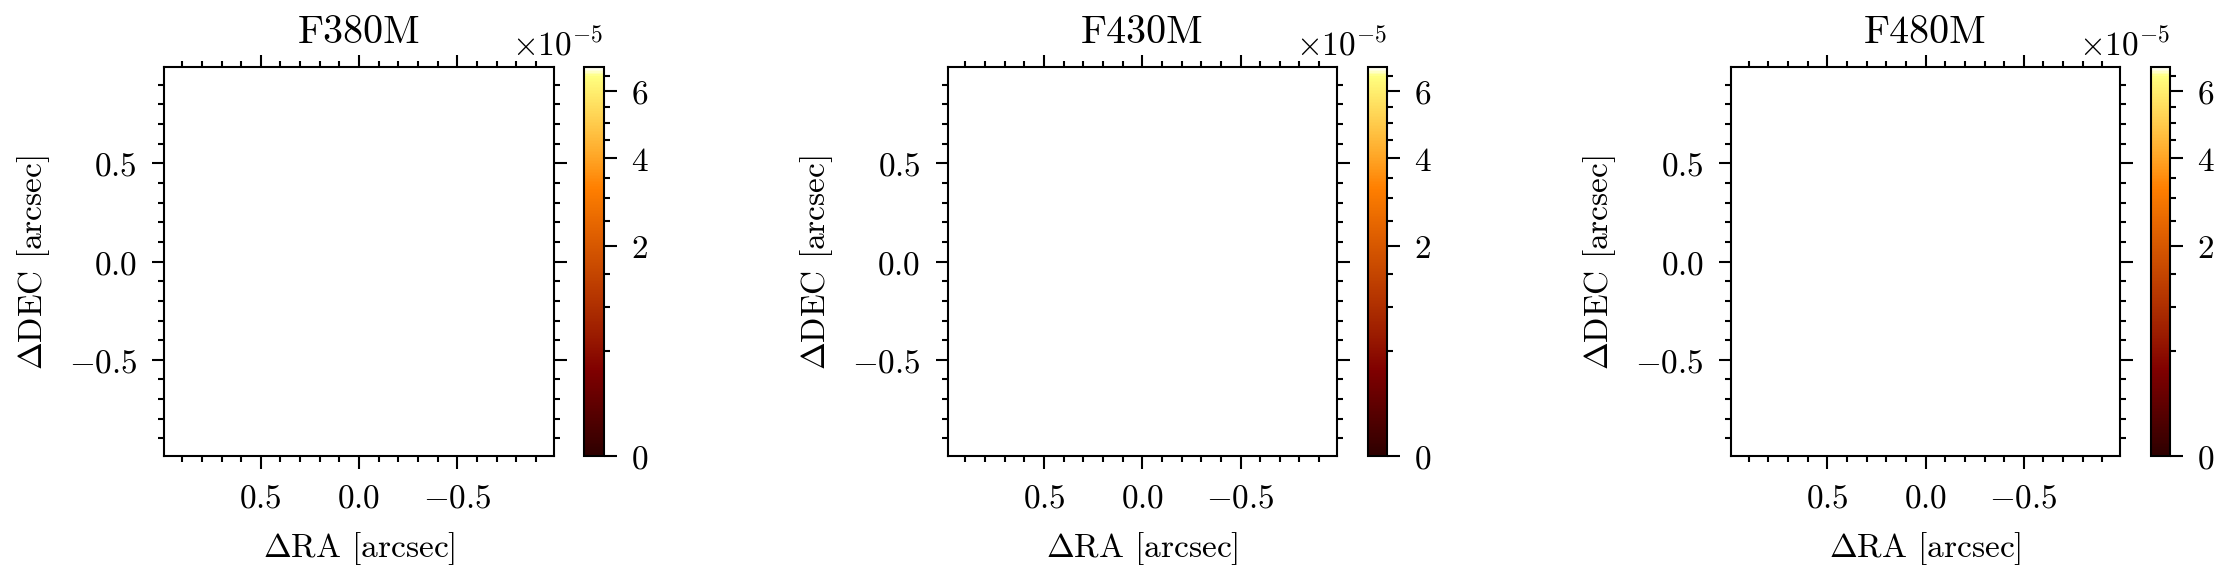

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(8, 2))

for idx, oi in enumerate(ois):

    init_dist = 10 ** model.params["log_dist"][oi.get_key("log_dist")]

    c0 = dorito.plotting.plot_result(
        ax[idx],
        init_dist,
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_10u",
    )
    fig.colorbar(c0, ax=ax[idx])
    ax[idx].set(title=oi.filter)

plt.tight_layout()
plt.show()

In [5]:
# import jax.scipy as jsp
# import jax.random as jr


# def difflim_to_cov(model, exposure, factor):

#     # calculating lambda over D
#     D = 6.603464  # m
#     lambda_on_D = dlu.rad2arcsec(exposure.wavel / D)

#     # calculating sigma, with some factor in front of lambda on D
#     sigma = dorito.misc.fwhm_to_sigma(factor * lambda_on_D)

#     # return covariance matrix
#     return [[sigma**2, 0], [0, sigma**2]]


# def blur_distribution(array, model, exposure, extent=0.25, factor=1.0):
#     cov = difflim_to_cov(model, exposure, factor)

#     x = np.arange(-extent, extent, dlu.rad2arcsec(model.pscale_in))
#     X, Y = np.meshgrid(x, x)
#     pos = np.dstack((X, Y))

#     kernel = jsp.stats.multivariate_normal.pdf(jr.PRNGKey(0), pos, np.array(cov))

#     distribution = jsp.signal.convolve2d(
#         array,
#         kernel,
#         mode="same",
#         # method="fft",
#     )
#     return distribution / distribution.sum()


def normalise_distribution(model_params, args):
    params = model_params.params

    if "log_dist" in params.keys():
        for k, log_dist in params["log_dist"].items():
            dist = 10**log_dist

            # # setting edges values to zero to avoid edge effects
            # n = 10
            # dist = dist.at[-n:, :].set(1e-16)
            # dist = dist.at[:, -n:].set(1e-16)
            # dist = dist.at[:n, :].set(1e-16)
            # dist = dist.at[:, :n].set(1e-16)

            # normalising the distribution
            params["log_dist"][k] = np.log10(dist / dist.sum())

    return model_params.set("params", params), args


def looper(looper, loss_dict):
    loss = np.array([v[-1] for v in loss_dict.values()]).mean(0)
    looper.set_description(f"Loss: {loss:.3e}")


def phase_centre(model, oi):

    distribution = model.get_distribution(oi)

    # Tip/Tilt vectors (ramp in u,v)
    mu = oi.u / np.linalg.norm(oi.u)
    mv = oi.v / np.linalg.norm(oi.v)

    # to log visibilities
    cvis = oi.to_cvis(model, distribution)
    phase = np.angle(cvis)

    # calculating the phase centre of the distribution
    return np.hypot(np.dot(mu, phase), np.dot(mv, phase))


def centered_loss_fn(model, exposure, args, width=1e-3):
    posterior = dorito.stats.regularised_loss_fn(model, exposure, args)[0]

    # phase centre prior
    centre = phase_centre(model, exposure)
    posterior += -jax.scipy.stats.norm.logpdf(centre, loc=0.0, scale=width)

    return posterior, ()

In [6]:
n_epoch = 20000
config = {
    "log_dist": adam(2e-2, 0, (5000, 0.1)),
    # "log_dist": adam(5e-3, 0),
}
args = {
    "reg_dict": {
        "ME": (5e3, dorito.stats.ME),
    }
}

trainer = Trainer(
    # loss_fn=centered_loss_fn,
    loss_fn=dorito.stats.regularised_loss_fn,
    norm_fn=normalise_distribution,
    looper_fn=looper,
)

trainer = trainer.update_fishers(
    model=model,
    exposures=[],
    parameters=[],
)

# Train the model
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=ois,
    args=args,
)

0it [00:00, ?it/s]

  0%|          | 0/20000 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 33,158,150.80
Estimated run time: 0:04:02
Full Time: 0:26:40
Final Loss: 324,907.16


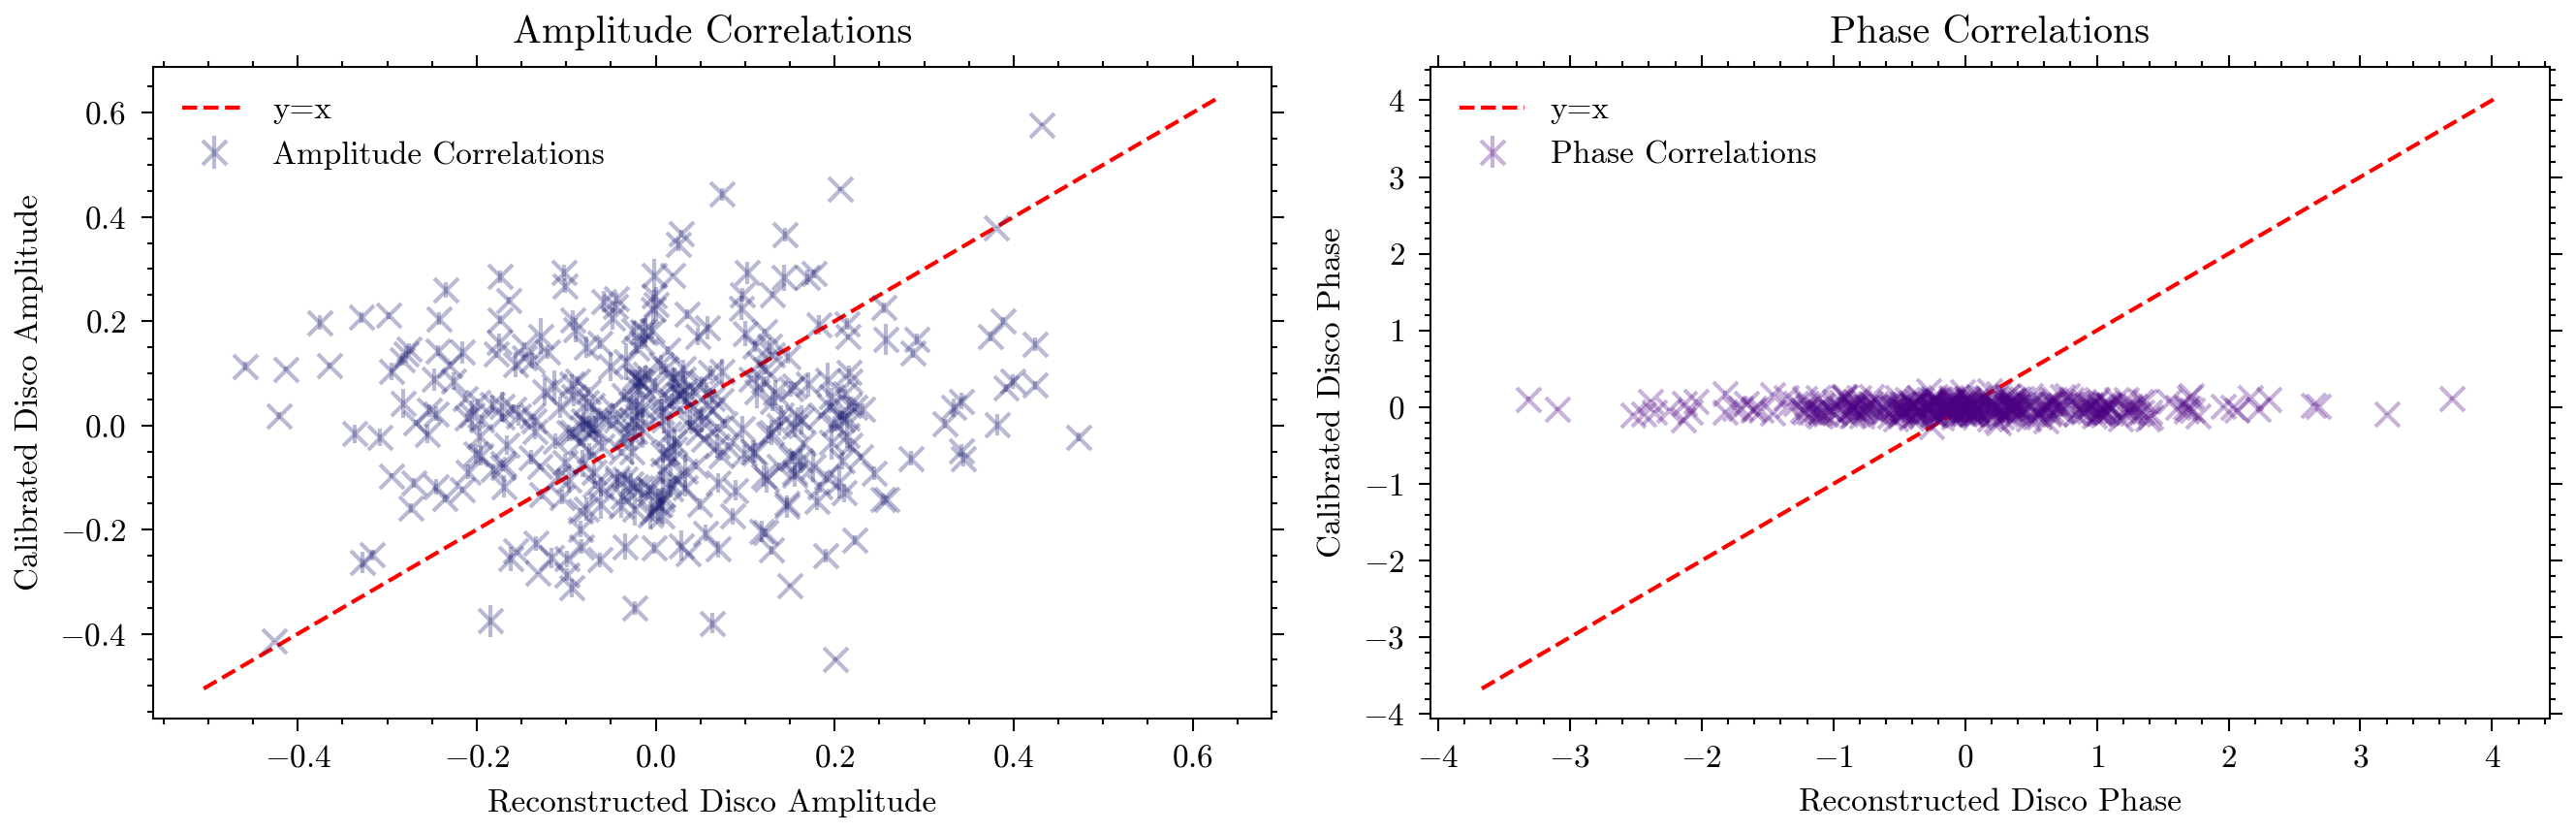

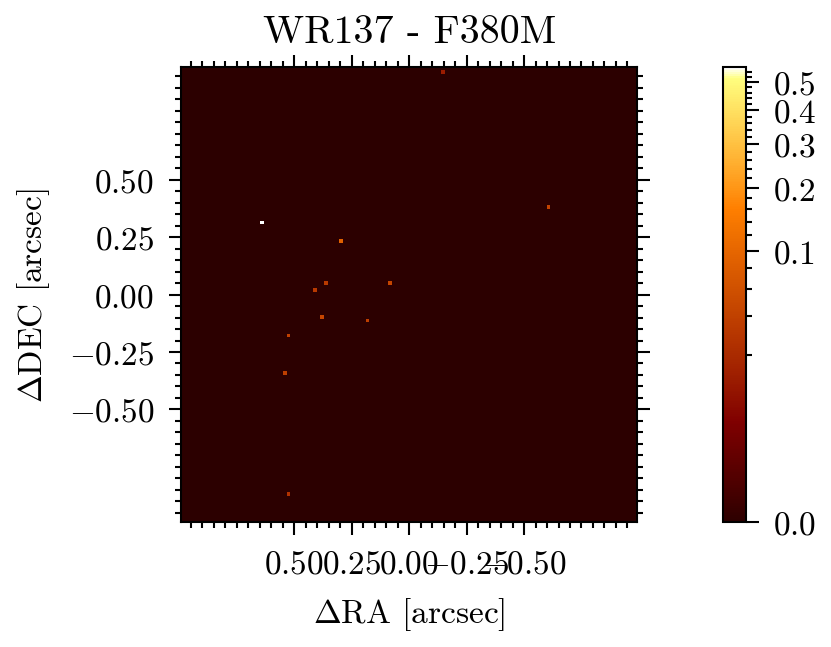

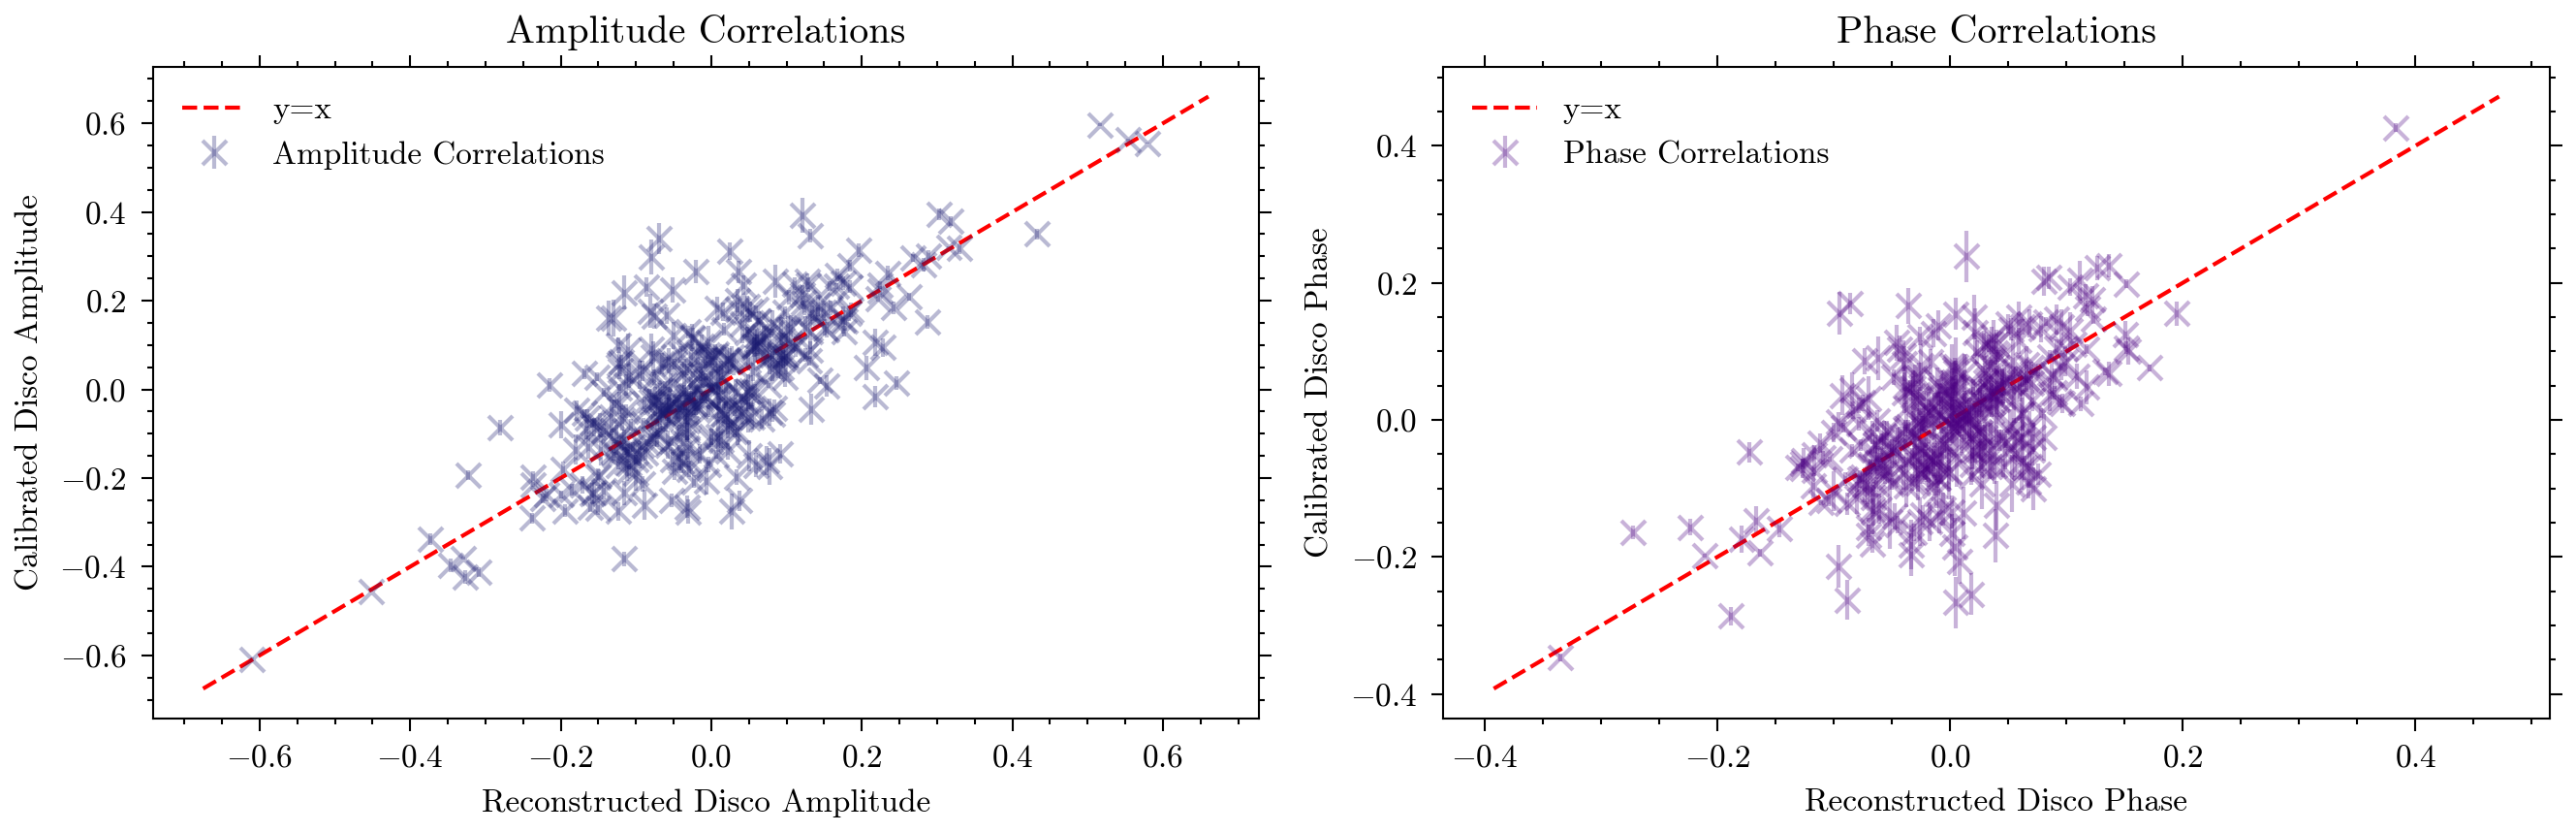

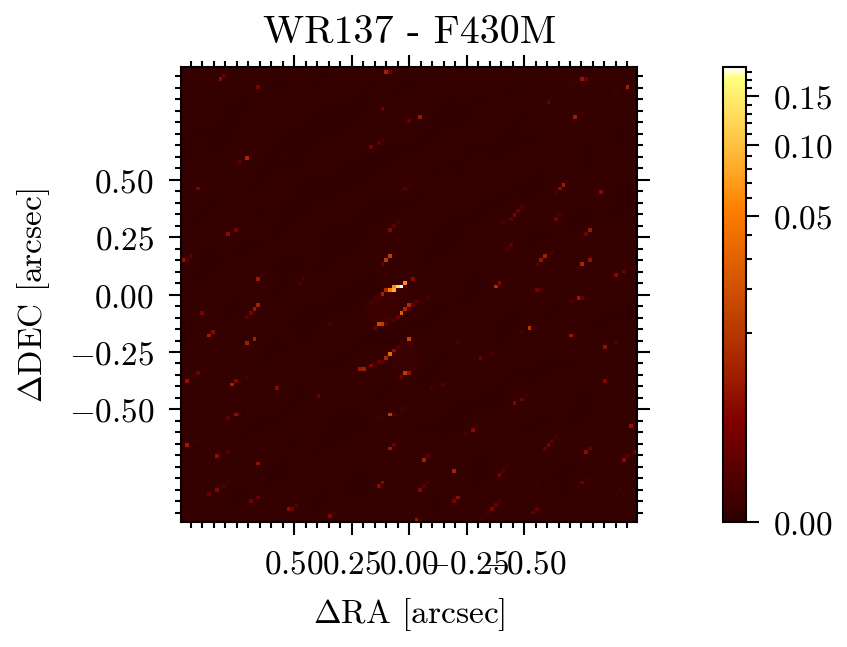

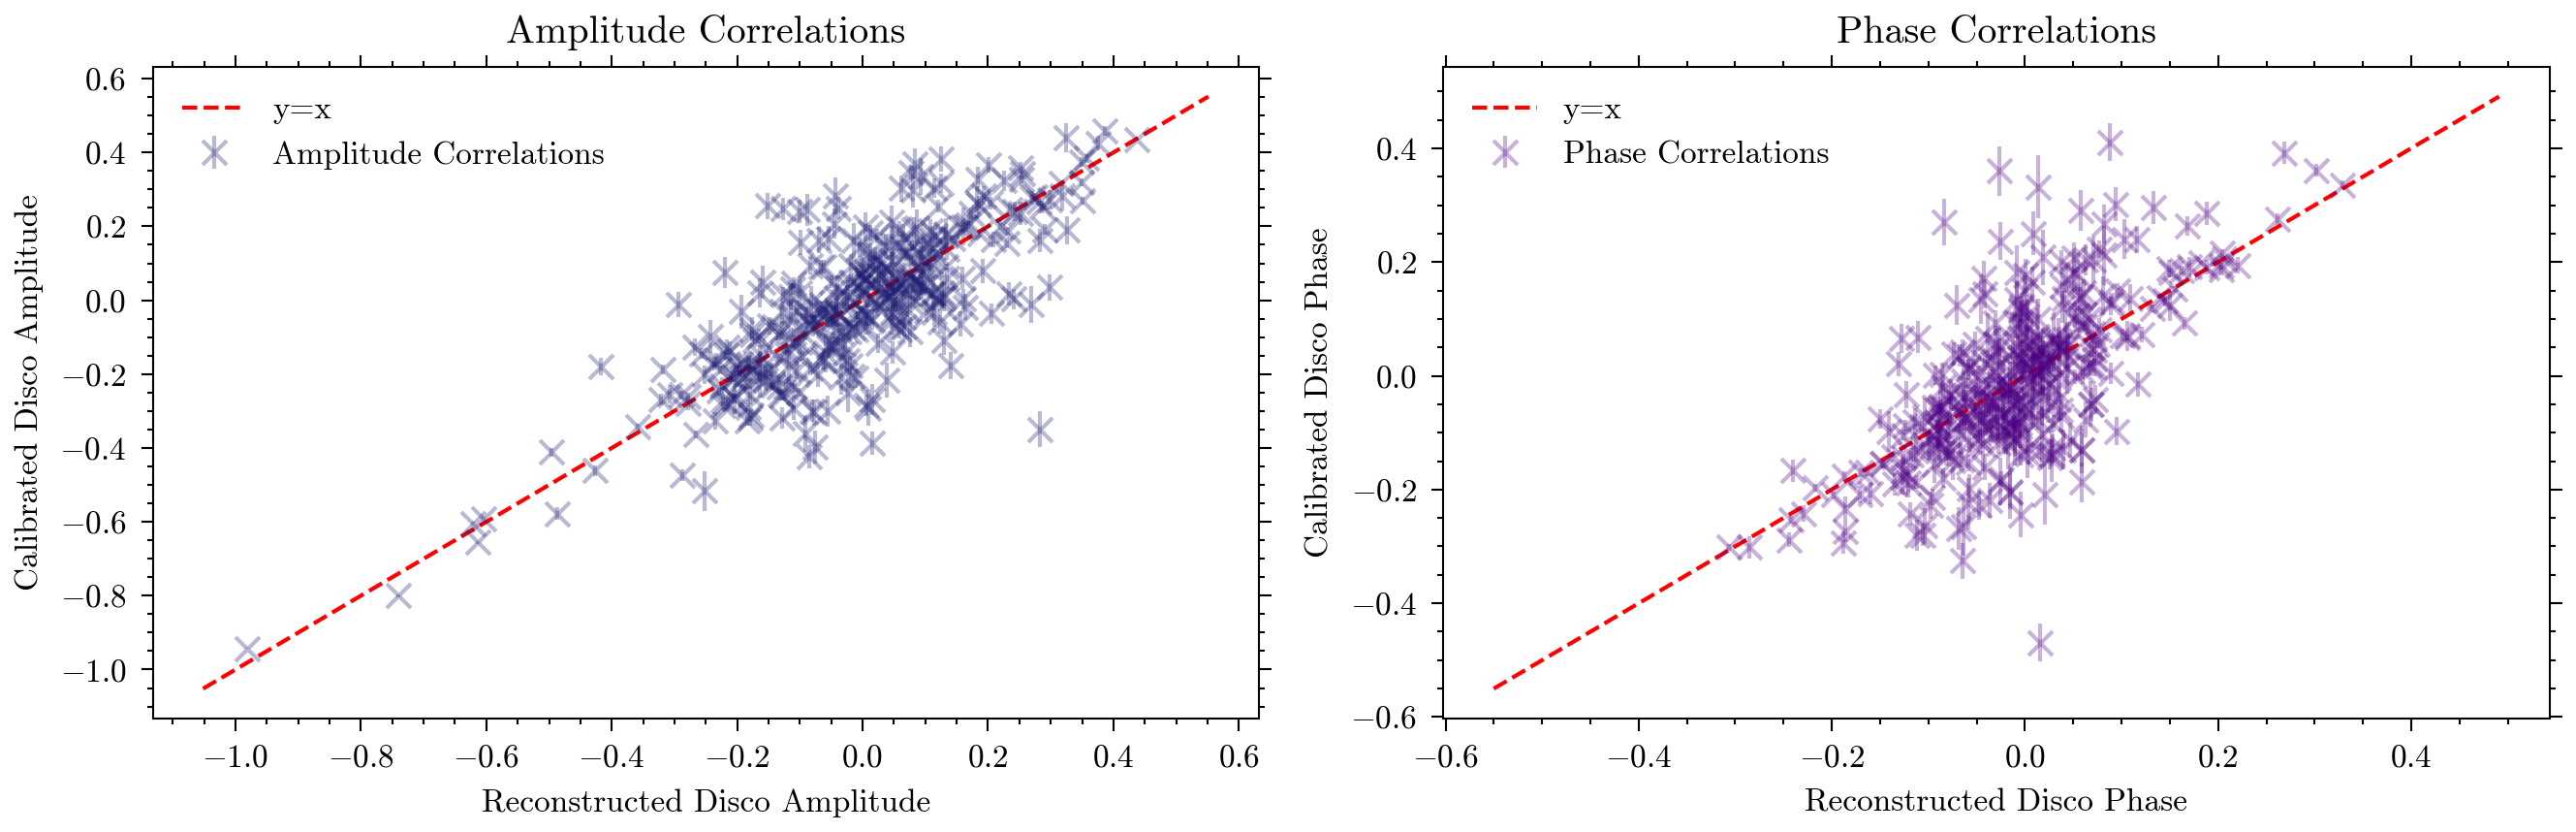

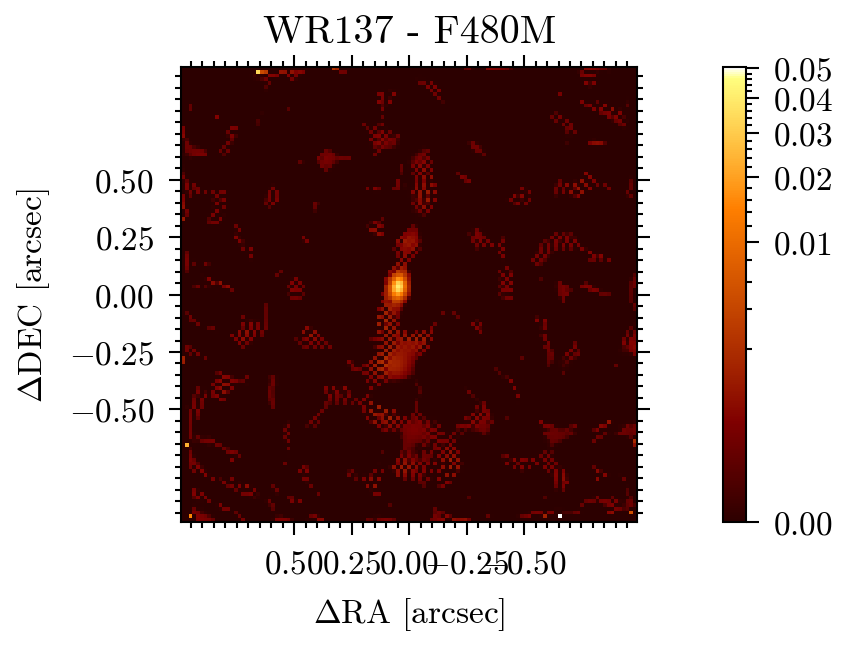

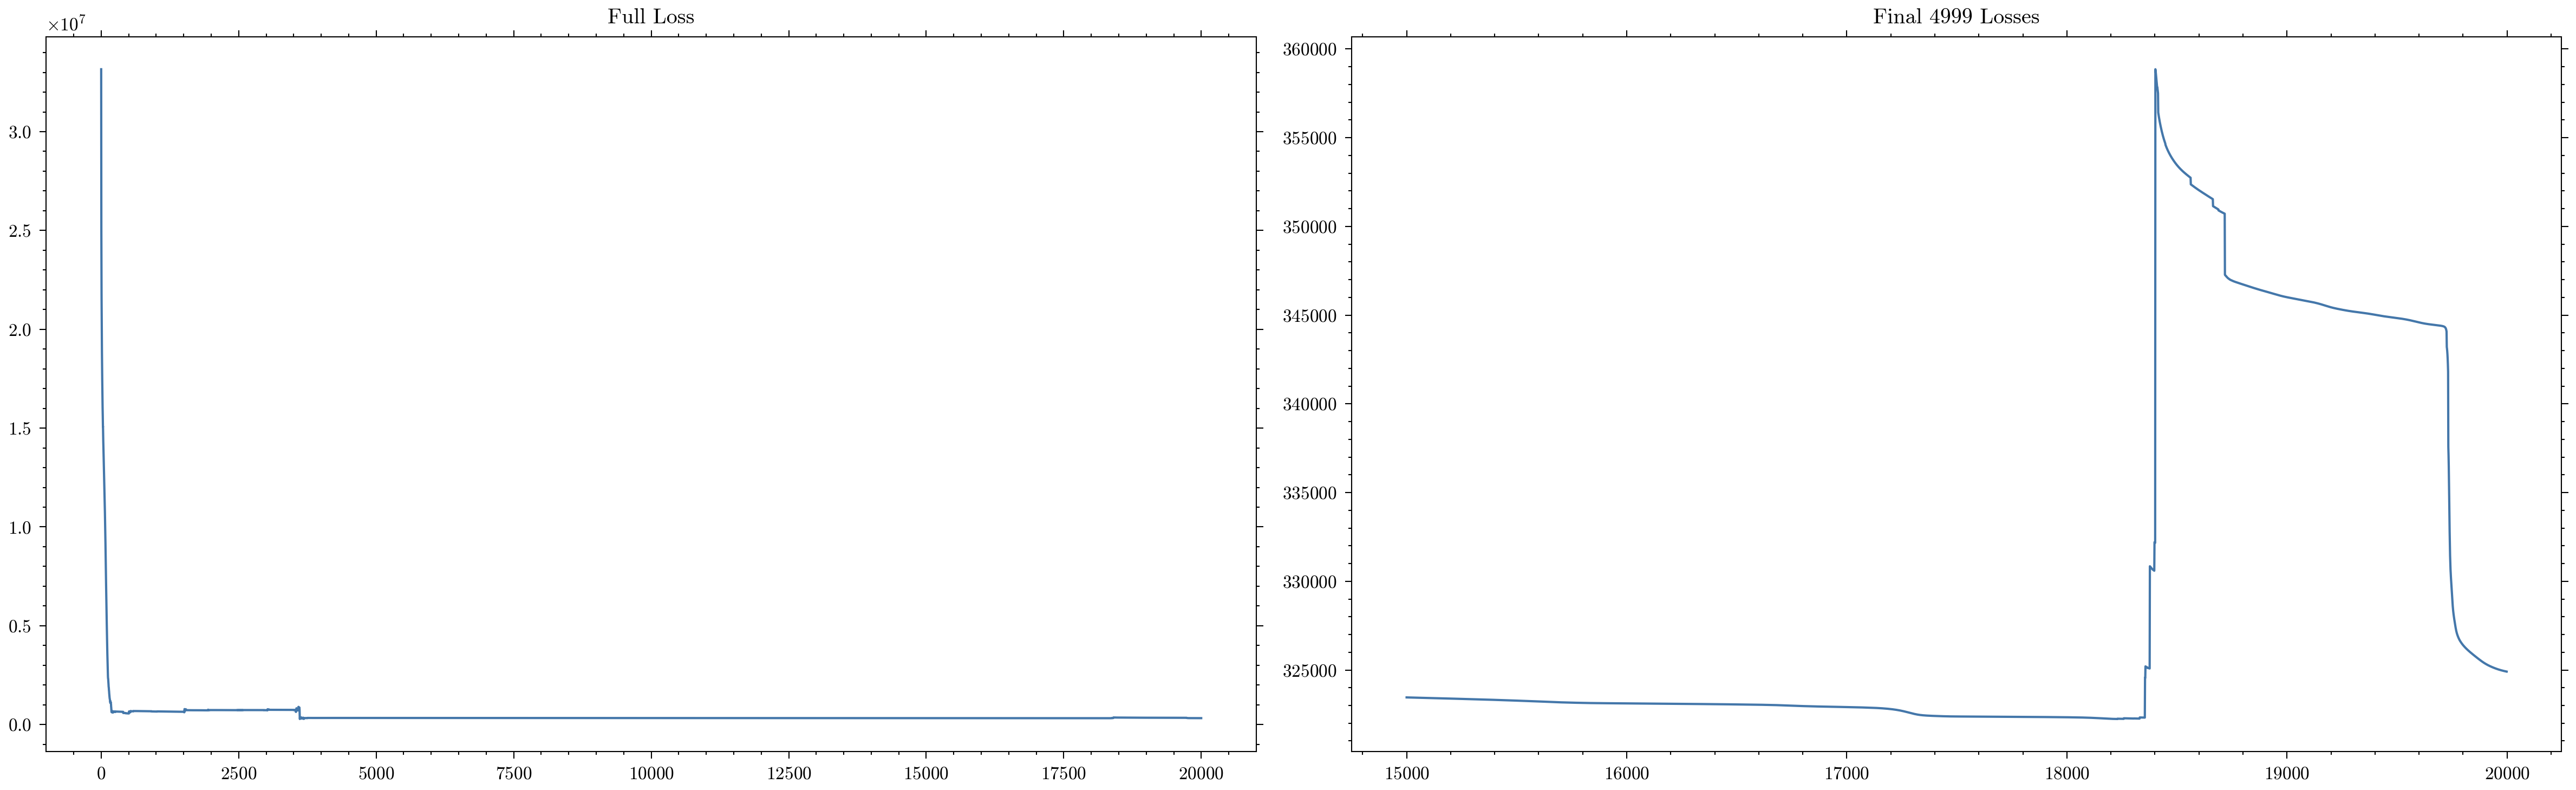

2025-06-25 12:11:53.354926: W external/xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.18GiB (rounded to 2342677248)requested by op 
2025-06-25 12:11:53.365986: W external/xla/xla/tsl/framework/bfc_allocator.cc:512] ********************************************************____****************************____________
E0625 12:11:53.372032 1843748 pjrt_stream_executor_client.cc:2839] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 2342677128 bytes. [tf-allocator-allocation-error='']
/home/max/miniforge3/envs/nuke/lib/python3.13/site-packages/amigo/plotting.py:396: SyntaxWarning: invalid escape sequence '\D'
  ax.set(ylabel="$\Delta$ Position (arcsec)")
/home/max/miniforge3/envs/nuke/lib/python3.13/site-packages/amigo/plotting.py:402: SyntaxWarning: invalid escape sequence '\D'
  ax.set(ylabel="$\Delta$ Flux (log)")
/home/max/miniforge3/envs/nuke/lib/python3.13/site-packages/amigo/plotting.py

ValueError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 2342677128 bytes.

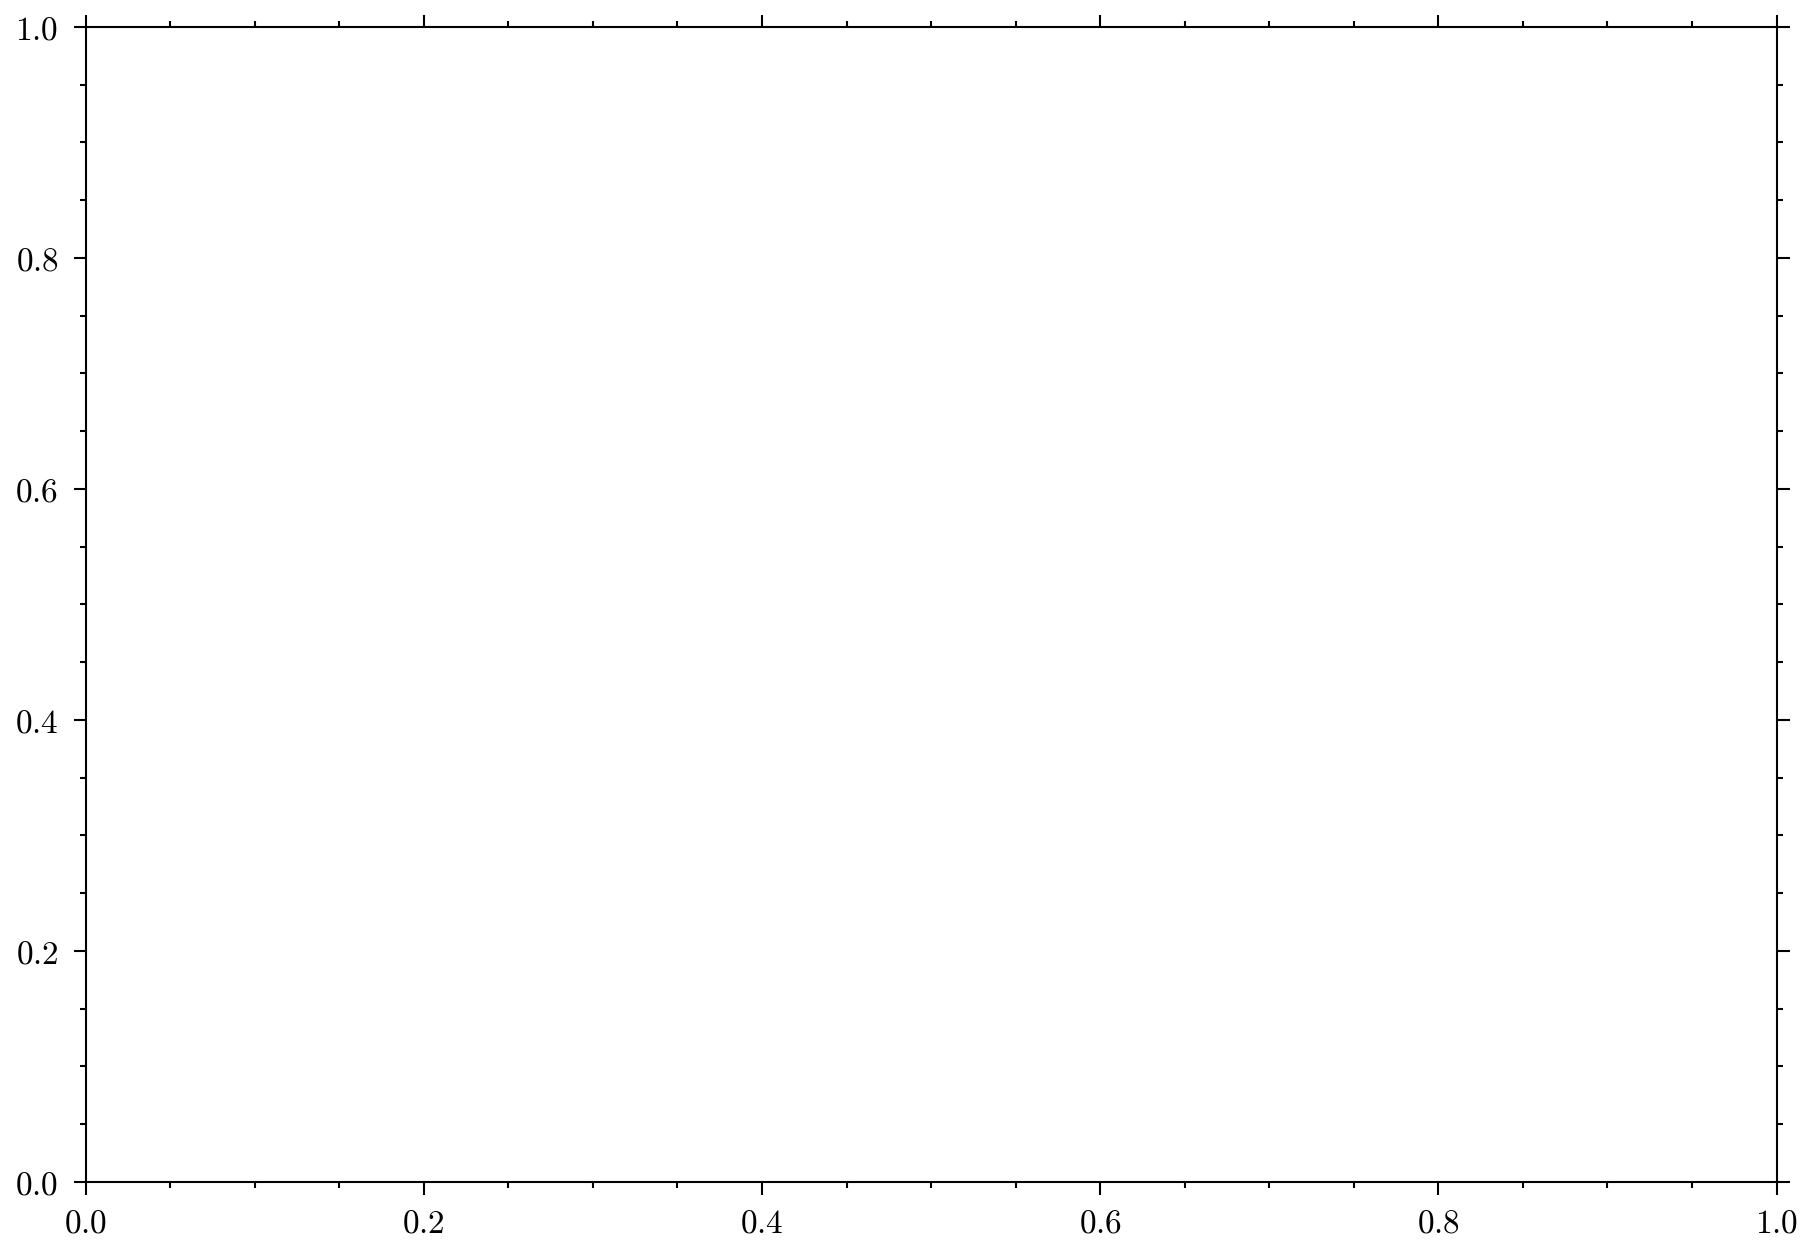

In [7]:
from amigo import plotting

for oi in ois:
    dist = result.model(oi, rotate=False)

    disco_amp, disco_phase = np.split(oi(result.model), 2)

    fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=False)

    ax[0].errorbar(
        disco_amp,
        oi.vis,
        yerr=oi.d_vis,
        label="Amplitude Correlations",
        fmt="x",
        alpha=0.3,
        color="midnightblue",
    )
    x_min, x_max = ax[0].get_xlim()
    y_min, y_max = ax[0].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[0].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[0].set_title("Amplitude Correlations")
    ax[0].set_xlabel("Reconstructed Disco Amplitude")
    ax[0].set_ylabel("Calibrated Disco Amplitude")
    ax[0].legend()

    ax[1].errorbar(
        disco_phase,
        oi.phi,
        yerr=oi.d_phi,
        label="Phase Correlations",
        fmt="x",
        alpha=0.3,
        color="indigo",
    )
    x_min, x_max = ax[1].get_xlim()
    y_min, y_max = ax[1].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[1].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[1].set_title("Phase Correlations")
    ax[1].set_xlabel("Reconstructed Disco Phase")
    ax[1].set_ylabel("Calibrated Disco Phase")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    ticks = [-0.5, -0.25, 0, 0.25, 0.5]

    fig, ax = plt.subplots(figsize=(6, 2.3))

    c0 = dorito.plotting.plot_result(
        ax,
        dist,
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_10u",
        power=0.3,
        vmin=0,
    )

    fig.colorbar(c0)

    ax.set(title=f"NGC1068 - {oi.key}", xticks=ticks, yticks=ticks)

    plt.tight_layout()
    plt.show()

plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
plotting.plot(result.history)

In [ ]:
import equinox as eqx
import optimistix as optx


def BFGS_logdist(
    model,
    exposures,
    reg_args,
    Solver=optx.BFGS,
    max_steps=2**16,
    rtol=1e-4,
    atol=1e-4,
):

    @eqx.filter_jit
    def fun(y, args):

        # unwrapping the args
        model, exp, reg_args = args

        # input is the log distribution
        log_dist = y

        # setting the model to the new log distribution
        params = model.params
        params["log_dist"][exp.get_key("log_dist")] = log_dist
        model = model.set("params", params)

        # calculating loss
        loss, _ = dorito.stats.regularised_loss_fn(model, exp, reg_args)

        sum_prior = -jax.scipy.stats.norm.logpdf(
            model.get_distribution(exp).sum(), loc=1.0, scale=1e-5
        )

        return loss + sum_prior

    args_out = {}
    sols_out = {}
    for exp in exposures:

        X = model.params["log_dist"][exp.get_key("log_dist")]
        args = (model, exp, reg_args)
        args_out[exp.key] = args

        print("Initial loss:", fun(X, args))
        solver = Solver(rtol=rtol, atol=atol)  # , verbose=frozenset({"loss"}))
        sol = optx.minimise(fun, solver, X, args, throw=False, max_steps=max_steps)
        sols_out[exp.key] = sol

        print("Final loss:", fun(sol.value, args))
        print(sol.stats["num_steps"], sol.state.num_accepted_steps)
        print(optx.RESULTS[sol.result])
        print()

    params = model.params
    for exp in ois:
        log_dist = sols_out[exp.key].value
        params["log_dist"][exp.get_key("log_dist")] = log_dist

    return model.set("params", params)


def joint_solve(
    model,
    exposures,
    reg_args,
    Solver=optx.BFGS,
    max_steps=2**16,
    rtol=1e-4,
    atol=1e-4,
):

    @eqx.filter_jit
    def fun(y, args):

        # unwrapping the args
        model, exps, reg_args = args

        # input is the log distribution
        log_dist = y

        # setting the model to the new log distribution
        params = model.params
        params["log_dist"][exps[0].get_key("log_dist")] = log_dist
        model = model.set("params", params)

        # calculating loss
        loss = [
            dorito.stats.regularised_loss_fn(model, exp, reg_args)[0] for exp in exps
        ]
        loss = np.array(loss).mean()

        sum_prior = -jax.scipy.stats.norm.logpdf(
            model.get_distribution(exps[0]).sum(), loc=1.0, scale=1e-5
        )

        return loss + sum_prior

    args_out = {}
    sols_out = {}

    for filt in ["F380M", "F430M", "F480M"]:

        exps = [oi for oi in exposures if oi.filter == filt]
        for exp in exps:
            print(exp.key)

        if len(exps) == 0:
            print(f"No exposures for filter {filt}, skipping initialisation.")
            continue

        X = model.params["log_dist"][filt]
        _args = (model, exps, reg_args)
        args_out[filt] = _args

        print("Initial loss:", fun(X, _args))
        solver = Solver(rtol=rtol, atol=atol)
        sol = optx.minimise(fun, solver, X, _args, throw=False, max_steps=max_steps)
        sols_out[filt] = sol

        print("Final loss:", fun(sol.value, _args))
        print(sol.stats["num_steps"], sol.state.num_accepted_steps)
        print(optx.RESULTS[sol.result])
        print()

    params = {"log_dist": {}, "base_uv": model.params["base_uv"]}
    for exp in ois:
        log_dist = sols_out[exp.filter].value
        params["log_dist"][exp.get_key("log_dist")] = log_dist

    return model.set("params", params)

In [ ]:
final_model = result.model


bfgs_model = BFGS_logdist(
    final_model,
    # model,
    ois,
    args,
    Solver=optx.BFGS,
    max_steps=2**16,
    rtol=1e-8,
    atol=1e-8,
)


# bfgs_model = joint_solve(
#     model,
#     # final_model,
#     ois,
#     args,
#     Solver=optx.LevenbergMarquardt,
#     max_steps=2**14,
#     rtol=1e-6,
#     atol=1e-6,
# )

# for oi in ois:
#     sol = sols_out[oi.filter]
#     print(oi.key)
#     print("Final loss:", fun(sol.value, _args))
#     # print(sol.result)

Initial loss: 76175.62385462713
Final loss: -1501.9908412110783
65536 40231
The maximum number of steps was reached in the nonlinear solver. The problem may not be solveable (e.g., a root-find on a function that has no roots), or you may need to increase `max_steps`.



In [ ]:
# np.save("files/71pix_os5.npy", bfgs_model.params, allow_pickle=True)
# np.save(output_path + "71pix_os5.npy", bfgs_model.params, allow_pickle=True)
# np.save(output_path + "121pix_os8.npy", bfgs_model.params, allow_pickle=True)

# params = np.load(output_path + "121pix_os8.npy", allow_pickle=True).item()
# bfgs_model = model.set("params", params)

1.0000000767416477
Loss: -1.491e+03


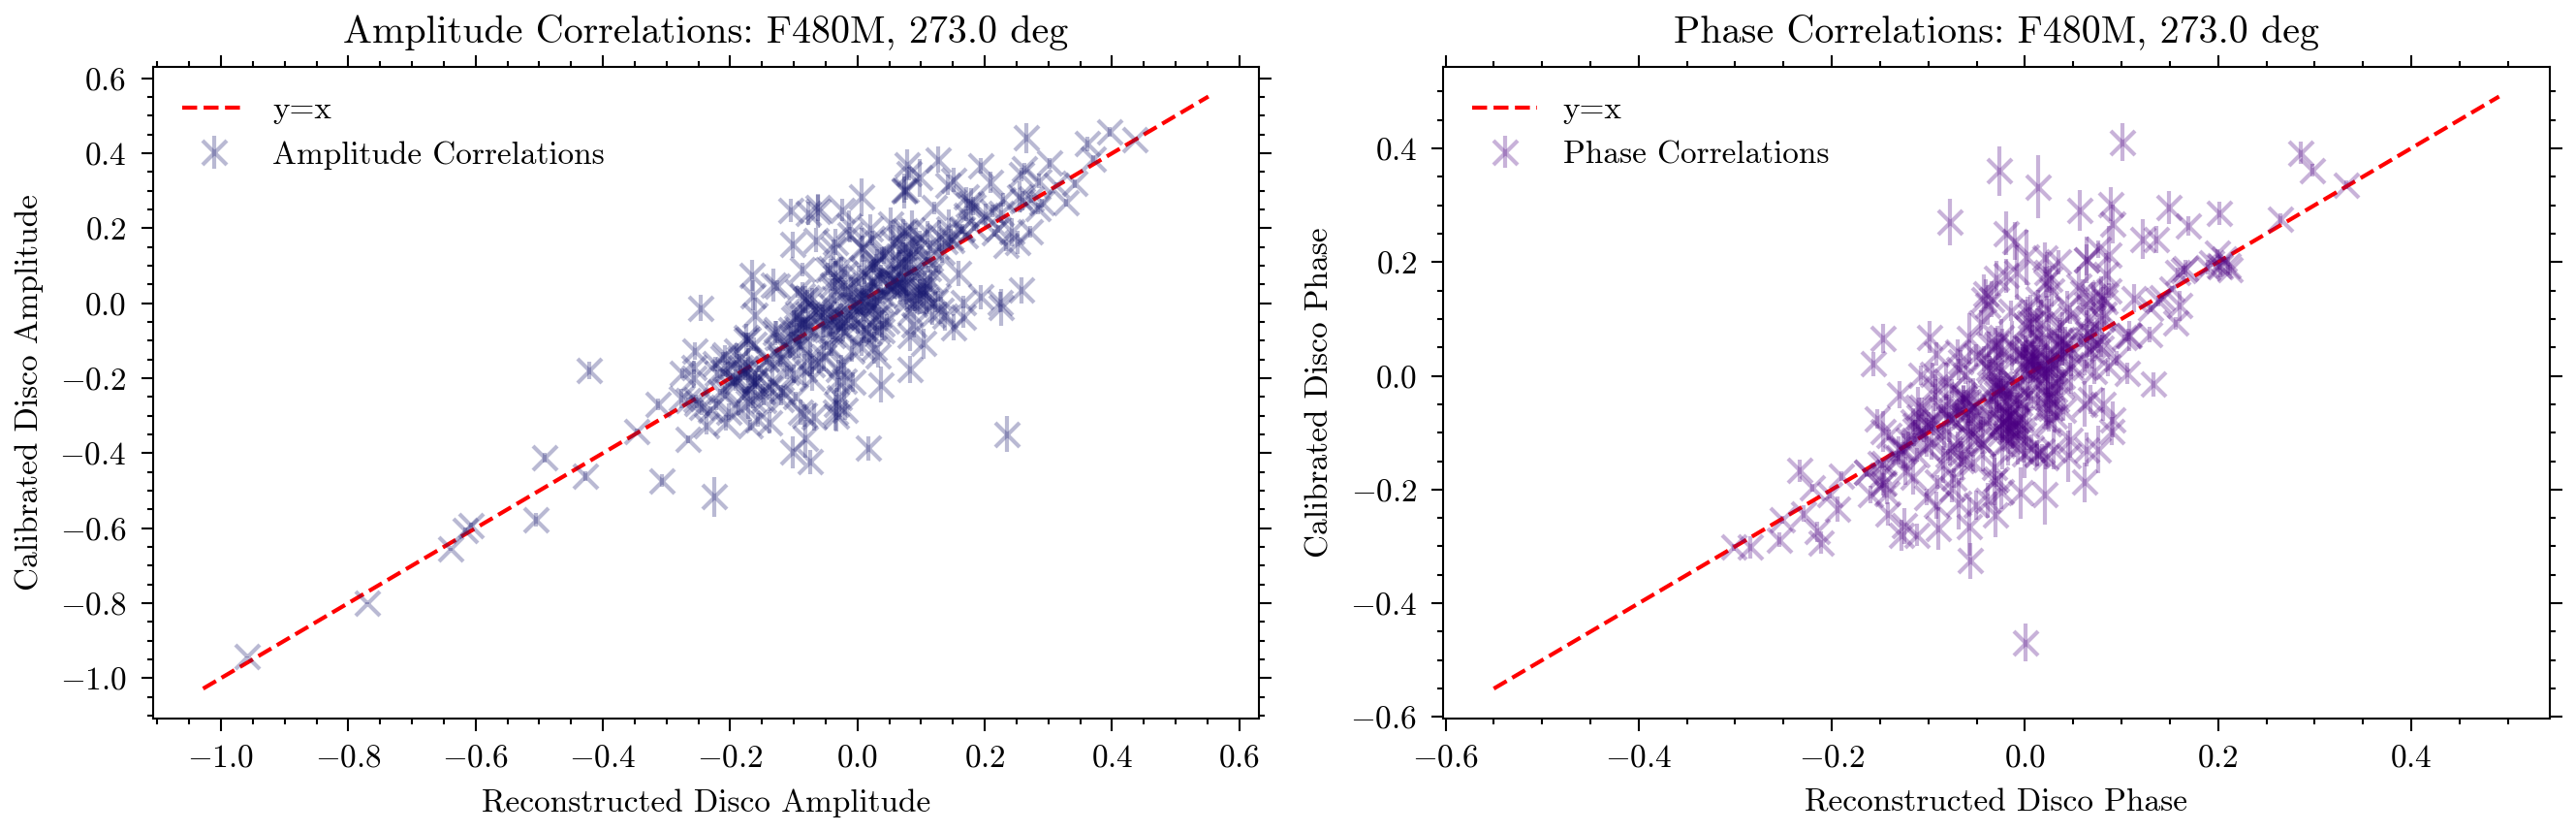

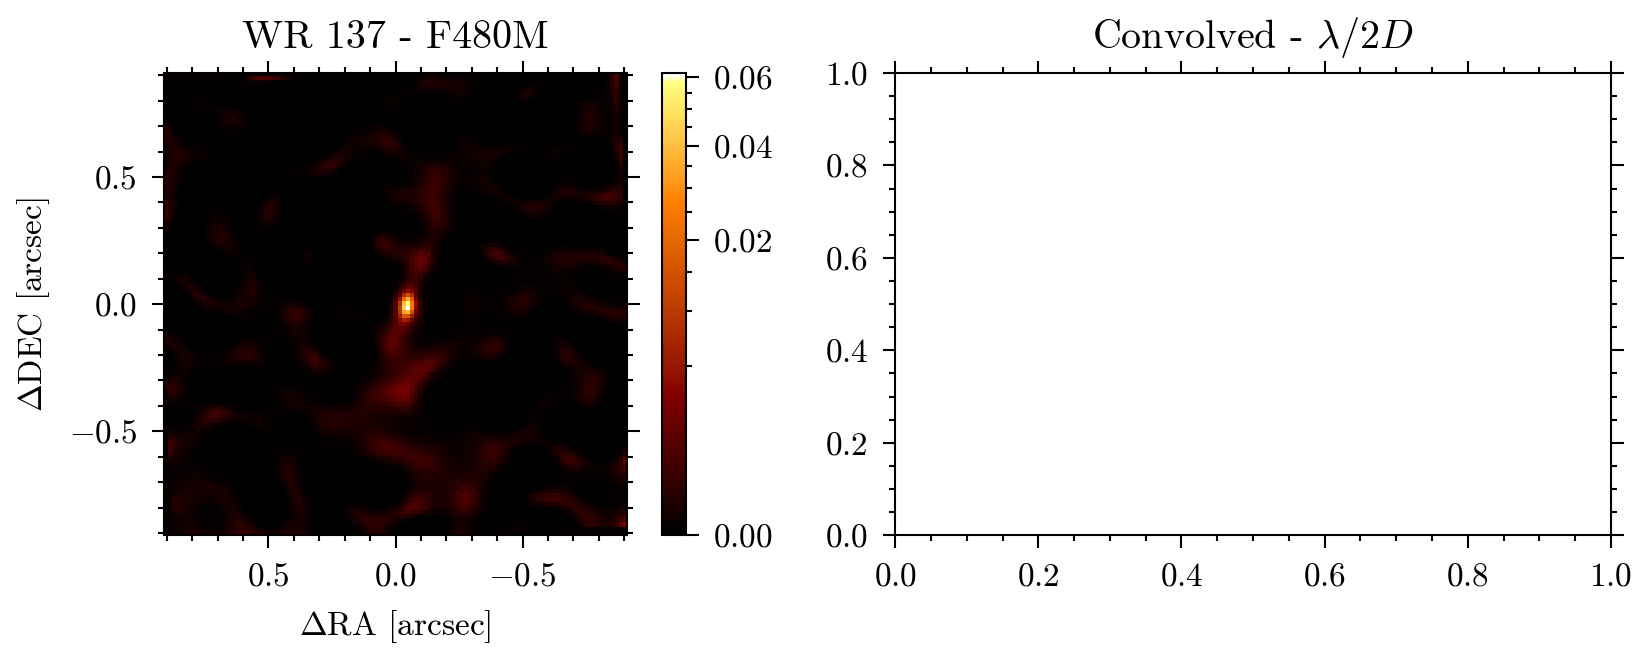

In [ ]:
for oi in ois:

    print(bfgs_model.get_distribution(oi).sum())
    # print(phase_centre(bfgs_model, oi))
    loss = dorito.stats.regularised_loss_fn(bfgs_model, oi, args)[0]
    print(f"Loss: {loss:.3e}")

    dist = 10 ** bfgs_model.params["log_dist"][oi.get_key("log_dist")]

    disco_amp, disco_phase = np.split(oi(bfgs_model), 2)

    fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=False)

    ax[0].errorbar(
        disco_amp,
        oi.vis,
        yerr=oi.d_vis,
        label="Amplitude Correlations",
        fmt="x",
        alpha=0.3,
        color="midnightblue",
    )
    x_min, x_max = ax[0].get_xlim()
    y_min, y_max = ax[0].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[0].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[0].set_title(f"Amplitude Correlations: {oi.filter}, {oi.parang:.1f} deg")
    ax[0].set_xlabel("Reconstructed Disco Amplitude")
    ax[0].set_ylabel("Calibrated Disco Amplitude")
    ax[0].legend()

    ax[1].errorbar(
        disco_phase,
        oi.phi,
        yerr=oi.d_phi,
        label="Phase Correlations",
        fmt="x",
        alpha=0.3,
        color="indigo",
    )
    x_min, x_max = ax[1].get_xlim()
    y_min, y_max = ax[1].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[1].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[1].set_title(f"Phase Correlations: {oi.filter}, {oi.parang:.1f} deg")
    ax[1].set_xlabel("Reconstructed Disco Phase")
    ax[1].set_ylabel("Calibrated Disco Phase")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    ticks = [-0.4, -0.2, 0, 0.2, 0.4]

    fig, ax = plt.subplots(1, 2, figsize=(6, 2.3))

    c0 = dorito.plotting.plot_result(
        ax[0],
        dist,
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_u",
        power=0.4,
        vmin=0,
    )

    # c1 = dorito.plotting.plot_result(
    #     ax[1],
    #     blur_distribution(dist, model, oi, factor=0.5),
    #     pixel_scale=dlu.rad2arcsec(model.pscale_in),
    #     cmap="afmhot_u",
    #     power=0.5,
    #     vmin=None,
    # )
    # fig.colorbar(c1, ax=ax[1])

    fig.colorbar(c0)
    # pa = model.params["position_angles"][exp.key]

    ax[0].set_title(
        f"NGC1068 - {oi.filter}"  # - {model.params['position_angles'][exp.get_key('position_angles')]:.1f}deg"
    )
    ax[1].set(title=r"Convolved - $\lambda / 2D$")

    plt.tight_layout()
    plt.show()

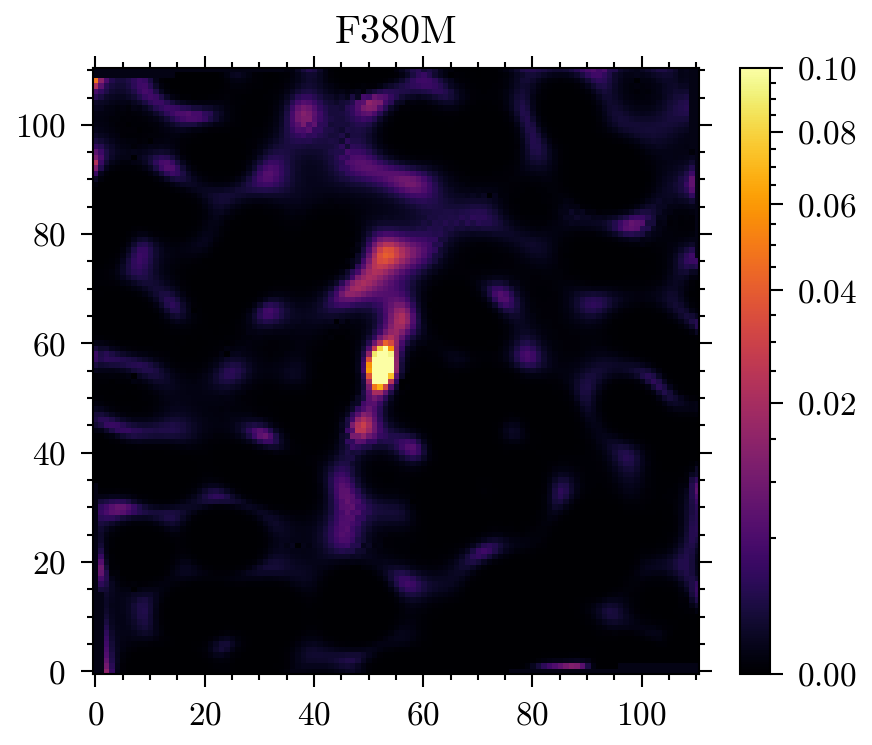

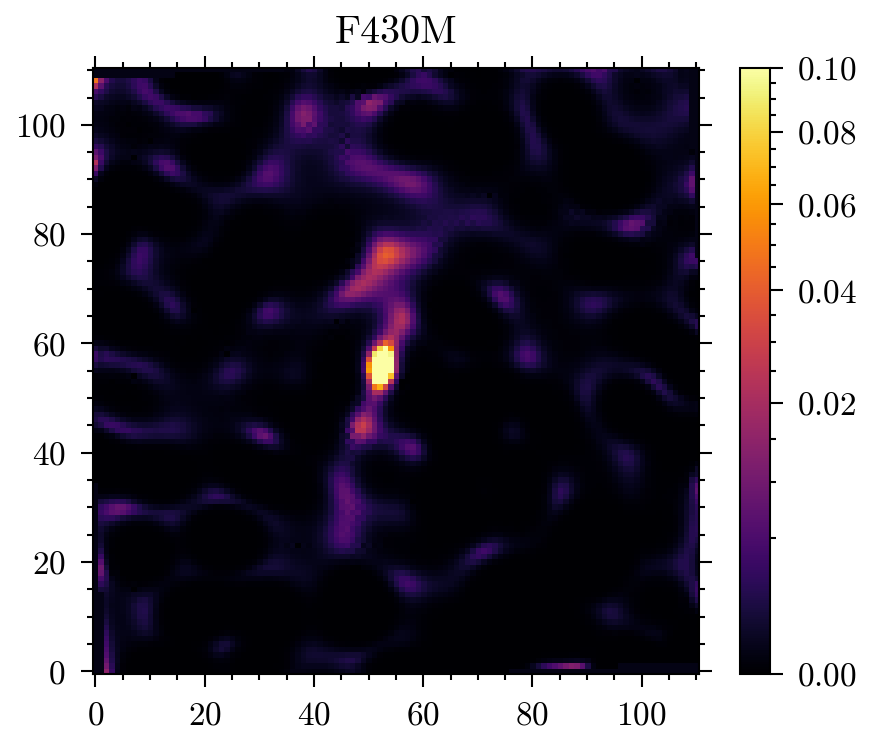

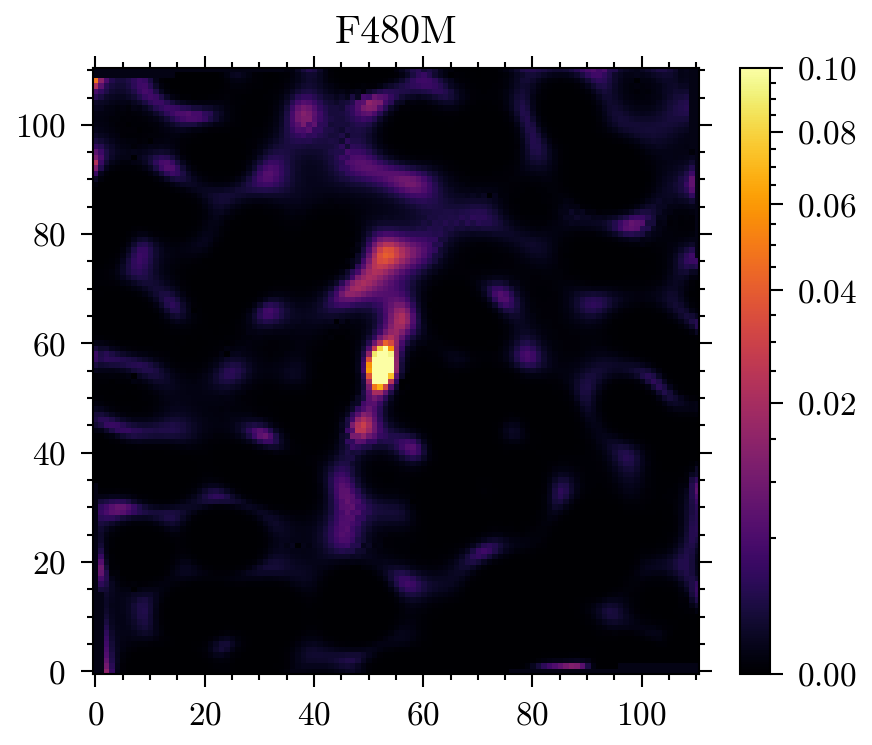

In [ ]:
for filt in ["F380M", "F430M", "F480M"]:
    dist = bfgs_model.get_distribution(oi, rotate=False)

    rl_dist = np.clip(dist + 1e-16)
    rl_dist = rl_dist / rl_dist.max()

    rl_dist = np.rot90(rl_dist, 2)
    plt.imshow(rl_dist, norm=mpl.colors.PowerNorm(0.5, vmin=0, vmax=1e-1))
    plt.title(filt)
    plt.colorbar()
    plt.show()